In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("../data/r4.2/file.csv", nrows=300000)
df.head()

,id,date,user,pc,filename,content
0,{L9G8-J9QE34VM-2834VDPB},01/02/2010 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1,{H0W6-L4FG38XG-9897XTEN},01/02/2010 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...
2,{M3Z0-O2KK89OX-5716MBIM},01/02/2010 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3,{E1I4-S4QS61TG-3652YHKR},01/02/2010 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4,{D4R7-E7JL45UX-0067XALT},01/02/2010 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8


In [2]:
df.tail()

,id,date,user,pc,filename,content
299995,{J2X3-V1GX93ML-1497DXKX},11/17/2010 15:24:14,JNJ0556,PC-0576,GB80SIN0.doc,D0-CF-11-E0-A1-B1-1A-E1 wider number too ludga...
299996,{E9J2-Z1EG24WO-9452LBQF},11/17/2010 15:24:28,BMG0917,PC-6688,8TTS5HBR.doc,D0-CF-11-E0-A1-B1-1A-E1 neither edward what tr...
299997,{V1E0-S7GU37OM-0765ZKMN},11/17/2010 15:25:02,ILH0958,PC-2181,5CILPY1B.jpg,FF-D8
299998,{M5Z0-H9OP35ED-5261DBLZ},11/17/2010 15:25:42,DBB0384,PC-4243,C6MHV8EN.jpg,FF-D8
299999,{Q8Z5-X9KK81DL-8673KKOU},11/17/2010 15:25:47,QRM0739,PC-7343,20WL68EK.doc,D0-CF-11-E0-A1-B1-1A-E1 less witnessed failing...


In [3]:
df.shape

(300000, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   id        300000 non-null  str  
 1   date      300000 non-null  str  
 2   user      300000 non-null  str  
 3   pc        300000 non-null  str  
 4   filename  300000 non-null  str  
 5   content   300000 non-null  str  
dtypes: str(6)
memory usage: 13.7 MB


In [5]:
df.describe()

,id,date,user,pc,filename,content
count,300000,300000,300000,300000,300000,300000
unique,300000,291196,253,937,300000,284749
top,{L9G8-J9QE34VM-2834VDPB},04/14/2010 14:43:32,HSB0196,PC-8001,EYPC9Y08.doc,FF-D8
freq,1,13,7444,7444,1,15252


In [6]:
df['user'].nunique()

253

In [7]:
df['user'].head(10)

0    MOH0273
1    MOH0273
2    HPH0075
3    HPH0075
4    HSB0196
5    RRC0553
6    RRC0553
7    RRC0553
8    MOH0273
9    RRC0553
Name: user, dtype: str

In [8]:
df['filename'].nunique()

300000

In [9]:
df['filename'].head(10)

0    EYPC9Y08.doc
1    N3LTSU3O.pdf
2    D3D3WC9W.doc
3    QCSW62YS.doc
4    AU75JV6U.jpg
5    8ICKVGMO.doc
6    BAO9D5H2.doc
7    1PO60RXU.doc
8    JS09VZOJ.doc
9    MJVNF4DQ.doc
Name: filename, dtype: str

In [10]:
df['pc'].nunique()

937

In [11]:
df['pc'].head(10)

0    PC-6699
1    PC-6699
2    PC-2417
3    PC-2417
4    PC-8001
5    PC-6672
6    PC-6672
7    PC-6672
8    PC-6699
9    PC-6672
Name: pc, dtype: str

In [12]:
df['file_type']=df['filename'].str.extract(r'(\.\w+)$')
print(df.file_type.head(10))

0    .doc
1    .pdf
2    .doc
3    .doc
4    .jpg
5    .doc
6    .doc
7    .doc
8    .doc
9    .doc
Name: file_type, dtype: str


In [13]:
df['file_type'].unique()

<StringArray>
['.doc', '.pdf', '.jpg', '.txt', '.zip', '.exe']
Length: 6, dtype: str

In [14]:
df['file_type'].value_counts()

file_type
.doc    192753
.pdf     58889
.txt     15519
.jpg     15496
.zip     15392
.exe      1951
Name: count, dtype: int64

In [15]:
df['file_type'].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
299995    False
299996    False
299997    False
299998    False
299999    False
Name: file_type, Length: 300000, dtype: bool

In [16]:
df['file_type'].value_counts(normalize=True)*100

file_type
.doc    64.251000
.pdf    19.629667
.txt     5.173000
.jpg     5.165333
.zip     5.130667
.exe     0.650333
Name: proportion, dtype: float64

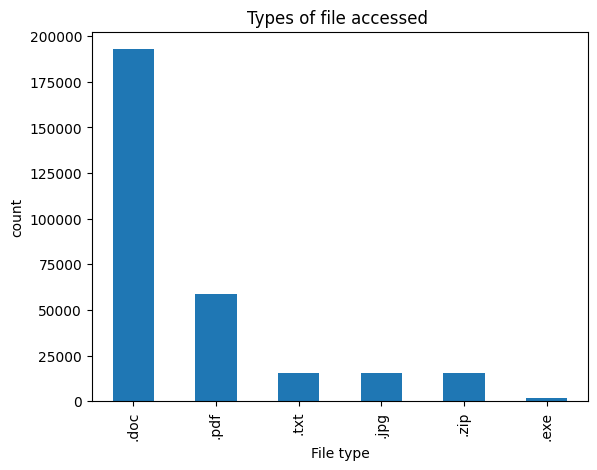

In [17]:
df['file_type'].value_counts().plot(kind='bar')
plt.title('Types of file accessed ')
plt.xlabel('File type')
plt.ylabel('count')
plt.show()

In [18]:
df.groupby('user')['file_type'].value_counts().head(23)

user     file_type
AAF0535  .doc         228
         .pdf          68
         .txt          23
         .jpg          23
         .zip          12
         .exe           3
AAM0658  .doc          17
         .pdf           6
         .txt           6
         .zip           1
         .jpg           1
ABC0174  .doc         319
         .pdf          97
         .zip          31
         .txt          30
         .jpg          22
         .exe           3
AHD0848  .doc          76
         .pdf          29
         .zip          10
         .jpg           8
         .txt           8
         .exe           2
Name: count, dtype: int64

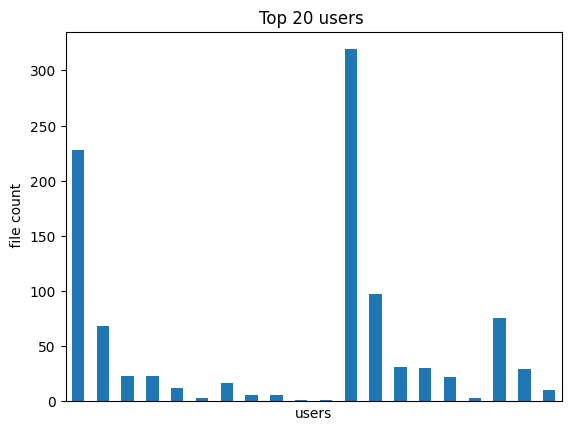

In [19]:
df.groupby('user')['file_type'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 users ')
plt.xticks([])
plt.xlabel('users')
plt.ylabel(' file count')
plt.show()

In [20]:

df['content'].head(10)

0    D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1    25-50-44-46-2D carpenters 25 landed strait dis...
2    D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3    D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4                                                FF-D8
5    D0-CF-11-E0-A1-B1-1A-E1 county one able 1367 h...
6    D0-CF-11-E0-A1-B1-1A-E1 special decided barrag...
7    D0-CF-11-E0-A1-B1-1A-E1 major became many 2010...
8    D0-CF-11-E0-A1-B1-1A-E1 yet chamberlain own co...
9    D0-CF-11-E0-A1-B1-1A-E1 identify 1942 communic...
Name: content, dtype: str

In [21]:
df[['magic_no','file_content']] = df['content'].str.split(' ', n=1, expand=True)
print(df[['magic_no','file_content']].head(10))

                  magic_no                                       file_content
0  D0-CF-11-E0-A1-B1-1A-E1  during difficulty overall cannons nonexistent ...
1           25-50-44-46-2D  carpenters 25 landed strait display channel bo...
2  D0-CF-11-E0-A1-B1-1A-E1  union 24 declined imposed brain employee 21 lo...
3  D0-CF-11-E0-A1-B1-1A-E1  becoming period begin general much 1989 earlie...
4                    FF-D8                                                NaN
5  D0-CF-11-E0-A1-B1-1A-E1  county one able 1367 has 50 which king replace...
6  D0-CF-11-E0-A1-B1-1A-E1  special decided barrages hanks john the major ...
7  D0-CF-11-E0-A1-B1-1A-E1  major became many 2010 suffered starting unwil...
8  D0-CF-11-E0-A1-B1-1A-E1  yet chamberlain own command heidelberg knighte...
9  D0-CF-11-E0-A1-B1-1A-E1  identify 1942 communications recalls escaped t...


In [22]:
df['file_content'].isnull()

0         False
1         False
2         False
3         False
4          True
          ...  
299995    False
299996    False
299997     True
299998     True
299999    False
Name: file_content, Length: 300000, dtype: bool

In [23]:
df.isnull().sum()

id                  0
date                0
user                0
pc                  0
filename            0
content             0
file_type           0
magic_no            0
file_content    15252
dtype: int64

In [24]:
df.isnull().sum()

id                  0
date                0
user                0
pc                  0
filename            0
content             0
file_type           0
magic_no            0
file_content    15252
dtype: int64

In [25]:
df.loc[df['file_content'].isnull()]

,id,date,user,pc,filename,content,file_type,magic_no,file_content
4,{D4R7-E7JL45UX-0067XALT},01/02/2010 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8,.jpg,FF-D8,NaN
77,{Q2O9-N0EZ82VC-2675HMHK},01/02/2010 13:53:13,BRS0734,PC-4785,MKIA7GR4.jpg,FF-D8,.jpg,FF-D8,NaN
126,{Z4N5-J0IH32FD-2911IGSK},01/02/2010 19:08:14,AOK0844,PC-4659,6P2U4I9Y.jpg,FF-D8,.jpg,FF-D8,NaN
142,{P2M4-F4XE53PG-0004YJQA},01/03/2010 09:11:44,BDI0533,PC-5883,P278TUHX.jpg,FF-D8,.jpg,FF-D8,NaN
160,{Q5V7-X1FJ30EW-4560RPMQ},01/03/2010 09:58:44,LBH0942,PC-3640,KH0WSEIV.jpg,FF-D8,.jpg,FF-D8,NaN
...,...,...,...,...,...,...,...,...,...
299907,{M4N7-A1NZ18WS-4268ROSG},11/17/2010 14:51:28,HRB0351,PC-0697,GB2KXMCV.jpg,FF-D8,.jpg,FF-D8,NaN
299943,{A5J6-G3SD82UY-5055DORG},11/17/2010 15:03:33,LBH0942,PC-3640,IHCNIYJG.jpg,FF-D8,.jpg,FF-D8,NaN
299972,{O9O5-G0UA23OI-1587TYBM},11/17/2010 15:17:12,MOH0273,PC-6699,DNPNAJOE.jpg,FF-D8,.jpg,FF-D8,NaN
299997,{V1E0-S7GU37OM-0765ZKMN},11/17/2010 15:25:02,ILH0958,PC-2181,5CILPY1B.jpg,FF-D8,.jpg,FF-D8,NaN


In [26]:
print(df.duplicated().sum())


0


In [27]:
df['date']=pd.to_datetime(df['date'])
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())


Min date: 2010-01-02 07:23:14
Max date: 2010-11-17 15:25:47


user activity analysis

In [28]:
# files accessed by each user 
file_access=df.groupby('user').size().sort_values(ascending=False)
print(file_access)


user
HSB0196    7444
AJF0370    7022
LBH0942    7010
DLM0051    6776
MPM0220    6689
           ... 
RAB0589       2
BBS0039       1
JGT0221       1
JTM0223       1
CSC0217       1
Length: 253, dtype: int64


Text(0, 0.5, 'count')

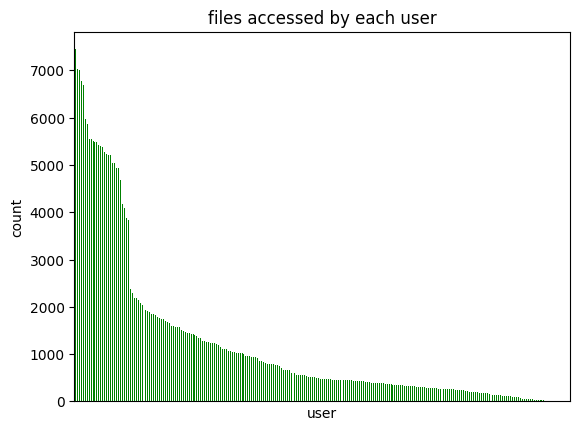

In [29]:
file_access.plot(kind='bar',color='green')
plt.xticks([])
plt.title('files accessed by each user')
plt.xlabel('user')
plt.ylabel('count')

In [30]:
file_access.head(10)

user
HSB0196    7444
AJF0370    7022
LBH0942    7010
DLM0051    6776
MPM0220    6689
HPH0075    5978
MOH0273    5869
DBB0384    5555
ZKS0899    5543
VIA0063    5507
dtype: int64

In [31]:
file_access.tail(10)

user
JMB0308    10
BLS0678     5
BTL0226     4
HJB0742     3
LJR0523     3
RAB0589     2
BBS0039     1
JGT0221     1
JTM0223     1
CSC0217     1
dtype: int64

Text(0, 0.5, 'file count')

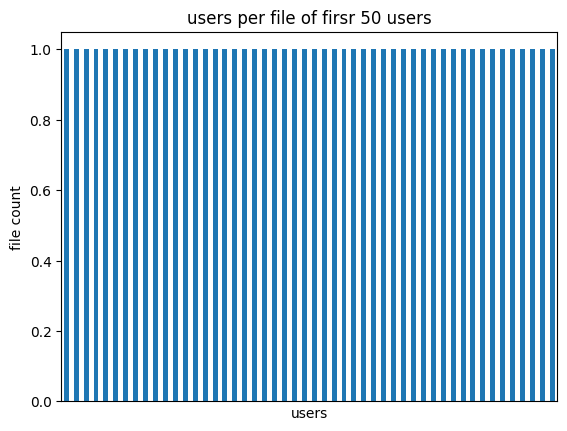

In [32]:
# users per file 
users_per_file = df.groupby("filename")["user"].nunique().head(50).sort_values(ascending=False).plot(kind='bar')
plt.title('users per file of firsr 50 users')
plt.xlabel('users')
plt.xticks([])
plt.ylabel('file count')


i.e each file is only accessed by one user

In [33]:
file_frequency =df.groupby("filename").size().sort_values(ascending=False)

print(file_frequency.head())

filename
0001OZOW.doc    1
O1NUN742.txt    1
O1QDKQ1P.doc    1
O1Q8QXI3.pdf    1
O1Q4RIMI.doc    1
dtype: int64


content analyisis

In [34]:
df['file_content'].duplicated()


0         False
1         False
2         False
3         False
4         False
          ...  
299995    False
299996    False
299997     True
299998     True
299999    False
Name: file_content, Length: 300000, dtype: bool

In [35]:
same_content_files = df.groupby('content')['filename'].nunique()
same_content_files = same_content_files[same_content_files > 1]

In [36]:
df[df['content'].isin(same_content_files.index)].sort_values('content')

,id,date,user,pc,filename,content,file_type,magic_no,file_content
4,{D4R7-E7JL45UX-0067XALT},2010-01-02 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8,.jpg,FF-D8,NaN
196065,{H0X5-H4AO15AQ-6779YZZO},2010-07-27 13:07:41,DIB0081,PC-9524,7IQ2QZJ6.jpg,FF-D8,.jpg,FF-D8,NaN
196079,{N6G2-W4EB83MP-8165KSEZ},2010-07-27 13:19:38,BJP0134,PC-0898,NFQ110IG.jpg,FF-D8,.jpg,FF-D8,NaN
196088,{P5A1-K2TJ77WX-1550PXUS},2010-07-27 13:33:35,QRM0739,PC-7343,2HS7DUZ8.jpg,FF-D8,.jpg,FF-D8,NaN
196138,{J6U6-L2HX97ZO-7439CSAX},2010-07-27 14:08:15,CIM0271,PC-3291,191FKAHJ.jpg,FF-D8,.jpg,FF-D8,NaN
...,...,...,...,...,...,...,...,...,...
97242,{C0C7-K7QN96XE-0596KUMI},2010-04-12 15:06:33,AJF0370,PC-8651,LM77GVPI.jpg,FF-D8,.jpg,FF-D8,NaN
97244,{R7S3-T6MI96BI-6279REYE},2010-04-12 15:07:21,AJF0370,PC-8651,98X0DE9M.jpg,FF-D8,.jpg,FF-D8,NaN
97246,{S9Q0-H7PR41ZV-1678ZREF},2010-04-12 15:08:12,LBH0942,PC-3640,4TK9M69K.jpg,FF-D8,.jpg,FF-D8,NaN
97129,{I4T2-X0OK24CQ-3610NNEA},2010-04-12 14:23:12,MCD0125,PC-7295,OHEM6K7L.jpg,FF-D8,.jpg,FF-D8,NaN


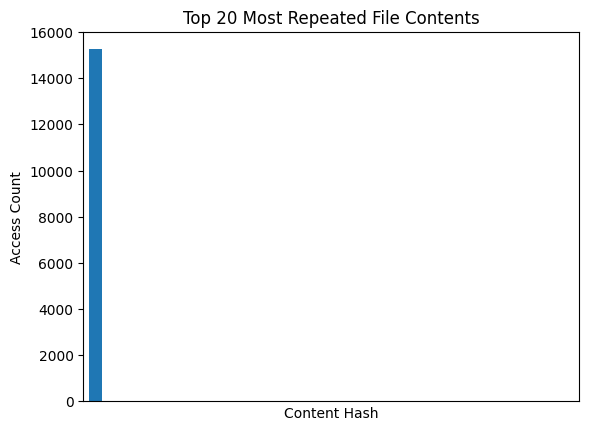

In [37]:
import matplotlib.pyplot as plt

df['content'].value_counts().head(20).plot(kind='bar')

plt.title("Top 20 Most Repeated File Contents")
plt.xticks([])
plt.xlabel("Content Hash")
plt.ylabel("Access Count")
plt.show()

there is one file with FF-D8 content which is repeted .

In [38]:
df[df['content'] == 'FF-D8'].shape[0]

15252

pc based analysis

In [39]:
# file accessed per pc
file_access_pc = df['pc'].value_counts()
print(file_access_pc)

pc
PC-8001    7444
PC-3640    7032
PC-0166    6801
PC-2417    5986
PC-6699    5874
           ... 
PC-3372       1
PC-8827       1
PC-9681       1
PC-9436       1
PC-5276       1
Name: count, Length: 937, dtype: int64


In [40]:
df['pc'].value_counts().head(10)

pc
PC-8001    7444
PC-3640    7032
PC-0166    6801
PC-2417    5986
PC-6699    5874
PC-4243    5586
PC-8517    5543
PC-2684    5511
PC-4804    5507
PC-4559    5501
Name: count, dtype: int64

In [41]:
df['pc'].value_counts().tail(10)

pc
PC-9261    1
PC-0494    1
PC-8610    1
PC-6377    1
PC-2948    1
PC-3372    1
PC-8827    1
PC-9681    1
PC-9436    1
PC-5276    1
Name: count, dtype: int64

In [42]:
users_per_pc = df.groupby('pc')['user'].nunique()
print(users_per_pc)

pc
PC-0004    4
PC-0008    1
PC-0039    2
PC-0044    2
PC-0072    3
          ..
PC-9966    3
PC-9973    1
PC-9979    3
PC-9988    5
PC-9999    4
Name: user, Length: 937, dtype: int64


In [43]:
shared_pcs = users_per_pc[users_per_pc > 1]
print(shared_pcs)

pc
PC-0004    4
PC-0039    2
PC-0044    2
PC-0072    3
PC-0092    4
          ..
PC-9939    4
PC-9966    3
PC-9979    3
PC-9988    5
PC-9999    4
Name: user, Length: 790, dtype: int64


In [44]:
df[df['pc'].isin(shared_pcs.index)].sort_values('pc')

,id,date,user,pc,filename,content,file_type,magic_no,file_content
246978,{L6K7-C9GH25WF-0247QJUE},2010-09-21 06:13:47,CCA0046,PC-0004,YRD6DV3Z.zip,D0-CF-11-E0-A1-B1-1A-E1 a announcement fourth ...,.zip,D0-CF-11-E0-A1-B1-1A-E1,a announcement fourth tube companies dlr their...
211317,{S3Z5-W5PP29PT-2954WPAJ},2010-08-12 07:30:14,MPM0220,PC-0004,KMTYD3RD.doc,D0-CF-11-E0-A1-B1-1A-E1 maintain zoo deity beh...,.doc,D0-CF-11-E0-A1-B1-1A-E1,maintain zoo deity behaviour sticks cliffs fou...
211316,{H7E5-Y5GU69TJ-9834OLCW},2010-08-12 07:30:13,MPM0220,PC-0004,EXBCKCGA.zip,D0-CF-11-E0-A1-B1-1A-E1 acid on upper or ecuad...,.zip,D0-CF-11-E0-A1-B1-1A-E1,acid on upper or ecuador locate recent emotion...
160575,{Y2B4-R4OB26VH-6151GCHO},2010-06-18 02:27:39,AJF0370,PC-0004,4EWW4VKO.doc,D0-CF-11-E0-A1-B1-1A-E1 resemble role exist fr...,.doc,D0-CF-11-E0-A1-B1-1A-E1,resemble role exist freshwater after absence d...
160576,{Y3Y2-T8SO17BE-3959YHNR},2010-06-18 02:27:57,AJF0370,PC-0004,B93MLRZS.doc,D0-CF-11-E0-A1-B1-1A-E1 evaluating strong indu...,.doc,D0-CF-11-E0-A1-B1-1A-E1,evaluating strong induces have imagery between...
...,...,...,...,...,...,...,...,...,...
193619,{F3I7-Z1GE98AZ-4780DRVL},2010-07-23 17:35:18,EIS0041,PC-9999,XB02NTUA.zip,50-4B-03-04-14 beginning penetrated borne also...,.zip,50-4B-03-04-14,beginning penetrated borne also informed seize...
200504,{X3Z2-G0SI27HY-4822UQHK},2010-07-30 18:36:26,HDS0367,PC-9999,NE4H1F66.doc,D0-CF-11-E0-A1-B1-1A-E1 review serving terminu...,.doc,D0-CF-11-E0-A1-B1-1A-E1,review serving terminus dark link state produc...
193620,{O4M6-R0GH30GY-2777RQYL},2010-07-23 17:35:19,EIS0041,PC-9999,IFSTTMVH.doc,D0-CF-11-E0-A1-B1-1A-E1 conference parachute b...,.doc,D0-CF-11-E0-A1-B1-1A-E1,conference parachute berlin due 1941 subsequen...
169891,{D2A3-Q1JJ84NF-9332LKLW},2010-06-29 04:06:17,IBB0359,PC-9999,F1SEKBEF.doc,D0-CF-11-E0-A1-B1-1A-E1 first france having fe...,.doc,D0-CF-11-E0-A1-B1-1A-E1,first france having february recipients outbre...


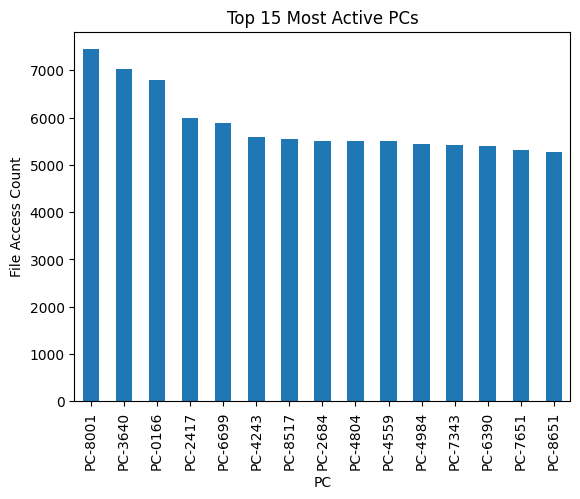

In [45]:
df['pc'].value_counts().head(15).plot(kind='bar')

plt.title("Top 15 Most Active PCs")
plt.xlabel("PC")
plt.ylabel("File Access Count")
plt.show()

time based analysis

In [46]:
print(df.columns)

Index(['id', 'date', 'user', 'pc', 'filename', 'content', 'file_type',
       'magic_no', 'file_content'],
      dtype='str')


In [47]:
# File Access per Hour
df['hour'] = df['date'].dt.hour
hourly_access = df['hour'].value_counts().sort_index()

print(hourly_access)

hour
0       809
1       909
2       812
3       954
4       807
5       897
6       959
7      6739
8     23420
9     32166
10    29793
11    26276
12    25945
13    29397
14    34631
15    33740
16    23265
17    14551
18     5727
19     2689
20     1657
21     1397
22     1268
23     1192
Name: count, dtype: int64


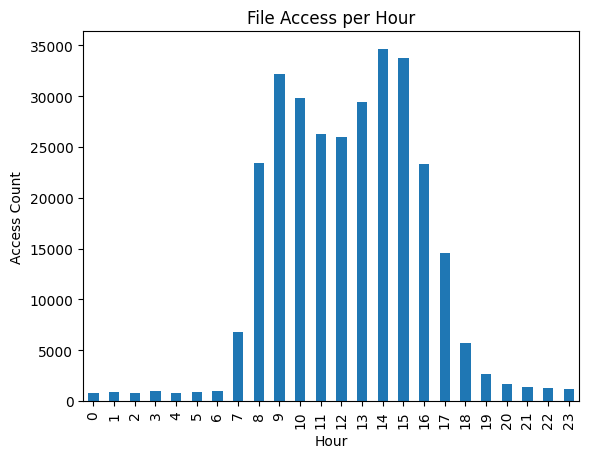

In [48]:
hourly_access.plot(kind='bar')
plt.title("File Access per Hour")
plt.xlabel("Hour")
plt.ylabel("Access Count")
plt.show()

In [49]:
df['day'] = df['date'].dt.date
daywise_access = df['day'].value_counts().sort_index()

print(daywise_access)

day
2010-01-02     128
2010-01-03     180
2010-01-04    1368
2010-01-05    1375
2010-01-06    1401
              ... 
2010-11-13     167
2010-11-14     122
2010-11-15    1239
2010-11-16    1191
2010-11-17     899
Name: count, Length: 320, dtype: int64


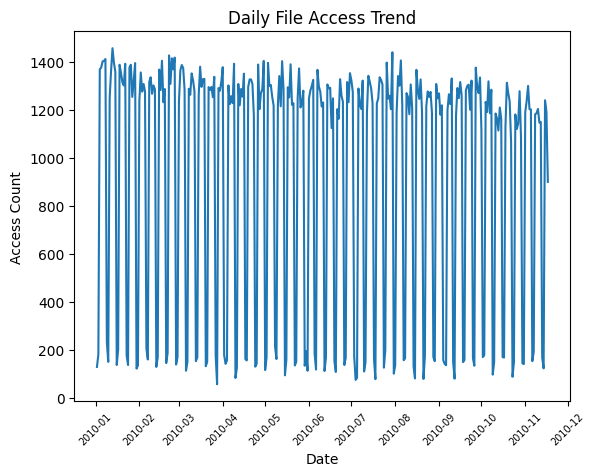

In [50]:
daywise_access.plot()
plt.title("Daily File Access Trend")
plt.xticks(rotation=45,size=7)
plt.xlabel("Date")
plt.ylabel("Access Count")
plt.show()

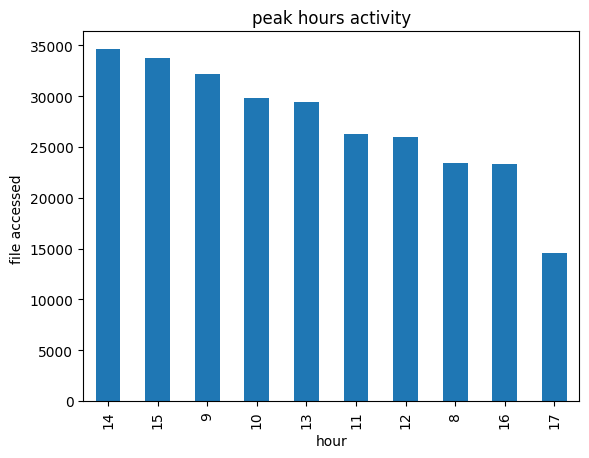

In [51]:
peak_hours = df['hour'].value_counts().head(10).plot(kind='bar')
plt.title('peak hours activity')
plt.ylabel('file accessed ')
plt.show()


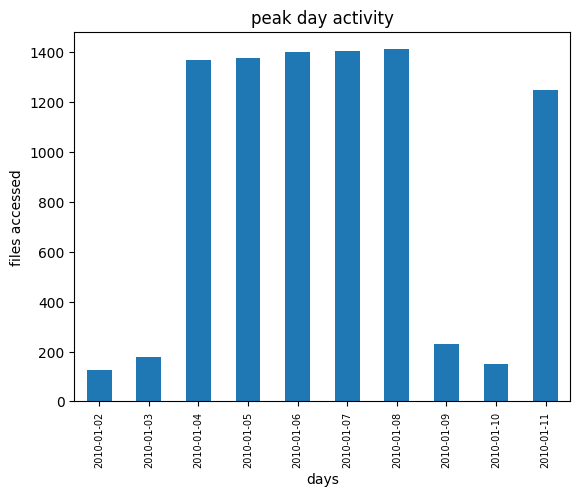

In [52]:
daywise_access.head(10).plot(kind='bar')
plt.xticks(size=7)
plt.xlabel('days')
plt.ylabel('files accessed')
plt.title('peak day activity')
plt.show()


In [53]:
suspicious = df[
    ((df['hour'] >= 23) | (df['hour'] <= 5)) &
    (df['pc'].notna())
]

print(suspicious.head(10))

                           id                date     user       pc  \
128  {B8B8-H8AO48KZ-1180PVIT} 2010-01-03 01:10:24  BSS0369  PC-8884   
129  {U1Z5-H4XP79XX-1132YMDD} 2010-01-03 01:10:24  BSS0369  PC-8884   
130  {B8U5-C0IK82JW-9171XPZU} 2010-01-03 01:10:25  BSS0369  PC-8884   
131  {G6W3-A2CB13CO-8109TJDO} 2010-01-03 01:10:26  BSS0369  PC-8884   
132  {P7O1-G2FE57DI-7334FIRR} 2010-01-03 01:10:26  BSS0369  PC-8884   
308  {O1H9-H8WI18UI-8480XLHM} 2010-01-04 00:20:23  MOS0047  PC-5909   
309  {O2B2-C6XW91KJ-2338TDYE} 2010-01-04 00:20:27  MOS0047  PC-5909   
310  {N0R7-X6UX54GT-5083BDDH} 2010-01-04 00:20:28  MOS0047  PC-5909   
311  {T1F2-J7RK25NJ-8688NUWW} 2010-01-04 00:20:29  MOS0047  PC-5909   
312  {S2Y1-S8RI29GY-4037HCOC} 2010-01-04 00:20:36  MOS0047  PC-5909   

         filename                                            content  \
128  8UXZMQOU.pdf  25-50-44-46-2D armistice ammunition positions ...   
129  E35HFMHR.doc  D0-CF-11-E0-A1-B1-1A-E1 19 one earned far live...   
13

------------------------------------------------------------------------------
Anomaly Indicator analysis 

In [54]:
# User accessing unusually high number of files.
file_access_count = df.groupby('user').size().reset_index(name='file_access_count')

threshold = file_access_count['file_access_count'].mean() + 2 * file_access_count['file_access_count'].std()

high_access_users = file_access_count[file_access_count['file_access_count'] > threshold]

print(high_access_users)

        user  file_access_count
8    AJF0370               7022
18   AVM0947               4931
29   BJM0111               5041
30   BJP0134               5217
32   BMG0917               4928
56   CLB0774               4682
64   DBB0384               5555
69   DLM0051               6776
100  HCM0267               5281
108  HPH0075               5978
111  HSB0196               7444
132  JDB0169               5052
143  JNJ0556               5202
156  LBH0942               7010
171  MDM0625               5414
176  MOH0273               5869
178  MPM0220               6689
203  QRM0739               5411
221  SAA0999               5486
233  THR0873               5493
240  VIA0063               5507
246  WIF0691               5382
251  XWD0923               5236
252  ZKS0899               5543


In [55]:
#User accessing many unique files
unique_files = df.groupby('user')['filename'].nunique().reset_index(name='unique_files_accessed')

print(unique_files)

        user  unique_files_accessed
0    AAF0535                    357
1    AAM0658                     31
2    ABC0174                    502
3    AHD0848                    133
4    AHM0410                   1375
..       ...                    ...
248  WXH0872                    562
249  XAA0104                    238
250  XHW0498                    386
251  XWD0923                   5236
252  ZKS0899                   5543

[253 rows x 2 columns]


In [56]:
#User accessing files from many PCs
pc_usage = df.groupby('user')['pc'].nunique().reset_index(name='unique_pc_used')

print(pc_usage)

        user  unique_pc_used
0    AAF0535               1
1    AAM0658               1
2    ABC0174               1
3    AHD0848               1
4    AHM0410               1
..       ...             ...
248  WXH0872               1
249  XAA0104               1
250  XHW0498               1
251  XWD0923               1
252  ZKS0899               1

[253 rows x 2 columns]


In [57]:
#Access outside working hours ..assume working hours as 9 AM – 6 PM
df['hour'] = df['date'].dt.hour

after_hours = df[(df['hour'] < 9) | (df['hour'] > 18)]

after_hours_access = after_hours.groupby('user').size().reset_index(name='after_hours_access')

print(after_hours_access)

        user  after_hours_access
0    AAM0658                  31
1    ABC0174                 113
2    AHD0848                  10
3    AHM0410                 150
4    AIB0948                 207
..       ...                 ...
224  WIQ0567                   3
225  WXH0872                  79
226  XAA0104                  40
227  XHW0498                  57
228  XWD0923                 326

[229 rows x 2 columns]


In [58]:
# Weekend access
df['date'] = pd.to_datetime(df['date'])

df['day'] = df['date'].dt.dayofweek
# Monday=0 ... Sunday=6

weekend_access = df[df['day'] >= 5]

weekend_access_count = weekend_access.groupby('user').size()
print(weekend_access_count)

user
ABC0174     62
AHD0848      9
AHM0410     13
AJD0074     15
AJF0370    319
          ... 
RSC0089     18
SBH0537     12
SBN0971    101
TDS0984    318
WIQ0567    283
Length: 62, dtype: int64


In [59]:
#File accessed by many users suddenly
users_per_file = df.groupby('filename')['user'].nunique().reset_index(name='unique_users')

print(users_per_file)

            filename  unique_users
0       0001OZOW.doc             1
1       0004I3A6.doc             1
2       0005D3AG.pdf             1
3       000G8ML5.doc             1
4       000HHROP.pdf             1
...              ...           ...
299995  ZZZKPLWG.doc             1
299996  ZZZL98WF.doc             1
299997  ZZZNWVUF.doc             1
299998  ZZZWFFNX.txt             1
299999  ZZZXWK9M.doc             1

[300000 rows x 2 columns]


In [60]:
#Same file accessed repeatedly
file_access_frequency = df.groupby(['user','filename']).size().reset_index(name='access_count')

repeated_access = file_access_frequency[file_access_frequency['access_count'] > 10]

print(repeated_access)

Empty DataFrame
Columns: [user, filename, access_count]
Index: []


In [61]:
# merging all the anamoly features 

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek


# 1. Total file access per user
file_access_count = df.groupby('user').size().reset_index(name='file_access_count')


# 2. Unique files accessed per user
unique_files = df.groupby('user')['filename'].nunique().reset_index(name='unique_files_accessed')


# 3. Unique PCs used by user
pc_usage = df.groupby('user')['pc'].nunique().reset_index(name='unique_pc_used')


# 4. Access outside working hours (before 9AM or after 6PM)
after_hours = df[(df['hour'] < 9) | (df['hour'] > 18)]

after_hours_access = after_hours.groupby('user').size().reset_index(name='after_hours_access')


# 5. Weekend access
weekend = df[df['day_of_week'] >= 5]

weekend_access_count = weekend.groupby('user').size().reset_index(name='weekend_access_count')


# 6. Repeated file access by same user
repeated_file_access = df.groupby(['user','filename']).size().reset_index(name='access_count')

repeated_file_access = repeated_file_access[repeated_file_access['access_count'] > 10]

repeated_file_access_count = repeated_file_access.groupby('user').size().reset_index(name='repeated_file_access_count')


# 7. Files accessed by many users
file_popularity = df.groupby('filename')['user'].nunique().reset_index(name='unique_users')


# -------------------------------
# Merge all user-level features
# -------------------------------

features = file_access_count.merge(unique_files, on='user', how='left')
features = features.merge(pc_usage, on='user', how='left')
features = features.merge(after_hours_access, on='user', how='left')
features = features.merge(weekend_access_count, on='user', how='left')
features = features.merge(repeated_file_access_count, on='user', how='left')


# Replace NaN with 0
features = features.fillna(0)


# -------------------------------
# Simple anomaly score
# -------------------------------

features['anomaly_score'] = (
    features['file_access_count'] +
    features['unique_files_accessed'] +
    features['unique_pc_used'] * 5 +
    features['after_hours_access'] * 3 +
    features['weekend_access_count'] * 3 +
    features['repeated_file_access_count'] * 4
)
# -------------------------------
# Calculate threat percentage
# -------------------------------

max_score = features['anomaly_score'].max()

features['threat_percentage'] = (features['anomaly_score'] / max_score) * 100

features['threat_percentage'] = features['threat_percentage'].round(2)


# Sort suspicious users
suspicious_users = features.sort_values(by='anomaly_score', ascending=False)


# Show top suspicious users
print(suspicious_users.head(10))

        user  file_access_count  unique_files_accessed  unique_pc_used  \
156  LBH0942               7010                   7010               1   
69   DLM0051               6776                   6776               1   
8    AJF0370               7022                   7022             286   
178  MPM0220               6689                   6689             244   
111  HSB0196               7444                   7444               1   
176  MOH0273               5869                   5869               1   
108  HPH0075               5978                   5978               1   
100  HCM0267               5281                   5281               1   
64   DBB0384               5555                   5555               1   
132  JDB0169               5052                   5052               1   

     after_hours_access  weekend_access_count  repeated_file_access_count  \
156              1551.0                1593.0                         0.0   
69               1905.0        